# 02 — NeuralODE, RK4, and multiple shooting

*The full dataset remains outside Git. These notebooks combine synthetic worked examples, aggregate evidence, and small attributed qualitative panels.*

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
plt.style.use("seaborn-v0_8-whitegrid")
summary = json.loads((ROOT / "reports" / "benchmark_summary.json").read_text())

## From tensors to an initial-value problem

The GRU reads only the 21 observed rows. Its final hidden state is context
$c$. A small network combines $c$, the current ODE state, and known time
features to produce a derivative. The solver—not the network—turns derivatives
into positions. This distinction helped me understand that a NeuralODE is not
"a neural network with time as one more label".

In [2]:
B,H,F=4,21,9
values=torch.randn(B,H,F); mask=(torch.rand(B,H,F)>.1).float()
encoder=torch.nn.GRU(input_size=2*F,hidden_size=32,batch_first=True)
_,hidden=encoder(torch.cat([values,mask],dim=-1))
context=hidden[-1]
z0=torch.zeros(B,4)  # [x, y, vx, vy]
field_input=torch.cat([z0,context,torch.zeros(B,3)],dim=-1)
print('history -> context:',tuple(values.shape),'->',tuple(context.shape))
print('field input [state, context, time features]:',tuple(field_input.shape))

history -> context: (4, 21, 9) -> (4, 32)
field input [state, context, time features]: (4, 39)


## What multiple shooting changes during training

I divide the 3 s target into shorter segments. Each segment is integrated with
shared parameters, while a boundary encoder proposes its training-only initial
state. The continuity penalty makes the end of segment $k$ agree with the
start of $k+1$:

\[
\mathcal L = \mathcal L_{path} + \lambda_c
\sum_k\|z_k(t_{k+1})-\tilde z_{k+1}\|_2^2.
\]

At inference I discard the boundary encoder and perform one causal rollout
from the anchor. The target can influence optimization, but it can never enter
`forward(history, mask)` at validation or test time.

segment boundaries: [0.   0.24 0.59]
continuity residuals: [ 0.01 -0.03]
path MSE=0.00028, continuity MSE=0.00050


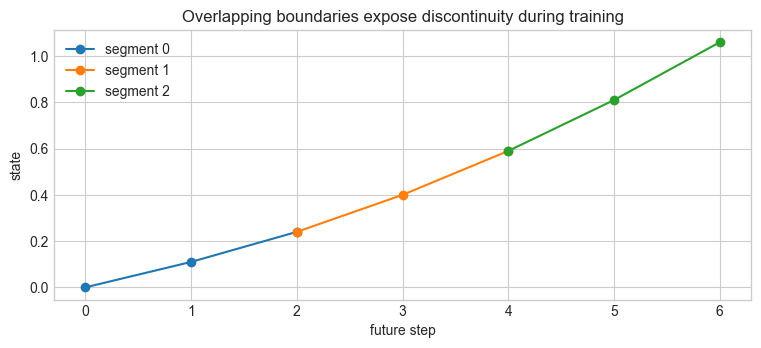

In [3]:
# A transparent one-dimensional shooting example.
target=np.array([0.,.11,.24,.40,.59,.81,1.06])
segments=[target[0:3],target[2:5],target[4:7]]
starts=np.array([s[0] for s in segments])
predicted_ends=np.array([.25,.56,1.03])
continuity=(predicted_ends[:-1]-starts[1:])**2
path_loss=np.mean((np.array([.10,.23,.39,.57,.80,1.03])-target[1:])**2)
print('segment boundaries:',starts)
print('continuity residuals:',predicted_ends[:-1]-starts[1:])
print(f'path MSE={path_loss:.5f}, continuity MSE={continuity.mean():.5f}')
fig,ax=plt.subplots(figsize=(9,3.5))
for k,s in enumerate(segments):
    x=np.arange(2*k,2*k+len(s)); ax.plot(x,s,'o-',label=f'segment {k}')
ax.set(xlabel='future step',ylabel='state',title='Overlapping boundaries expose discontinuity during training'); ax.legend(); plt.show()

## The hybrid state and its residual

The hybrid decoder integrates interpretable vehicle variables such as position,
heading, speed, and yaw rate. Kinematics provide the known derivative structure;
the learned residual corrects effects that are not represented by the simplified
model. Zero-initializing the residual head makes the first prediction equal to
the physical prior and provides a useful implementation check.

In [4]:
def bicycle_derivative(state,wheelbase=2.8):
    x,y,yaw,v,steer=state
    return np.array([v*np.cos(yaw),v*np.sin(yaw),v*np.tan(steer)/wheelbase,0.,0.])
states=[np.array([0.,0.,0.,8.,a]) for a in (-.08,0,.08)]
pd.DataFrame([bicycle_derivative(s) for s in states],index=['right','straight','left'],columns=['x_dot','y_dot','yaw_dot','v_dot','steer_dot']).round(4)

,x_dot,y_dot,yaw_dot,v_dot,steer_dot
right,8.0,0.0,-0.2291,0.0,0.0
straight,8.0,0.0,0.0000,0.0,0.0
left,8.0,0.0,0.2291,0.0,0.0


## Learning objectives and architecture

I want to understand what is continuous, what remains discrete, how RK4
produces predictions, why multiple shooting is a *training loss*, and what the
physics hybrid constrains.

```text
states B×21×9 + mask ──> GRU context c B×128 ──┐
current physical state ──> ODE initial state z0 ├─> RK4, 30 × 0.1 s ─> B×30×2
time features [t/H, sin(πt/H), cos(πt/H)] ─────┘
```

The history encoder is discrete because observations arrive on a fixed grid.
The future decoder is continuous because it defines $\dot z=f_\theta(z,c,t)$
and can in principle be queried using another integration step size.

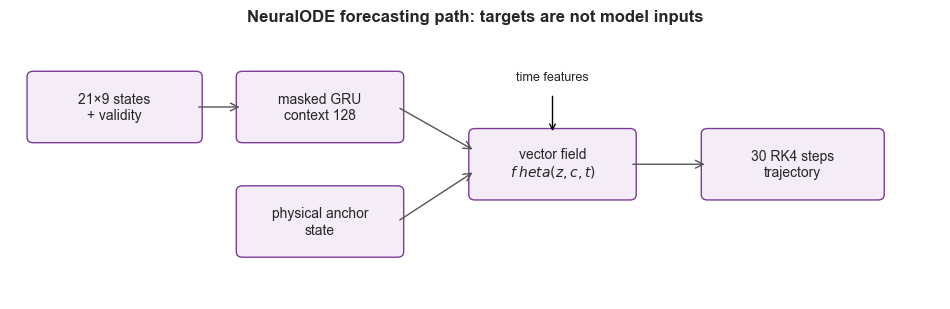

In [5]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
fig, ax = plt.subplots(figsize=(12,3.5)); ax.set_xlim(0,12); ax.set_ylim(0,4); ax.axis("off")
nodes=[(.3,2.4,2.1,.9,"21×9 states\n+ validity"),(3.0,2.4,2.0,.9,"masked GRU\ncontext 128"),
       (3.0,.7,2.0,.9,"physical anchor\nstate"),(6.0,1.55,2.0,.9,"vector field\n$f_\theta(z,c,t)$"),
       (9.0,1.55,2.2,.9,"30 RK4 steps\ntrajectory")]
for x,y,w,h,label in nodes:
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle="round,pad=.08",fc="#f4ecf7",ec="#7d3c98"))
    ax.text(x+w/2,y+h/2,label,ha="center",va="center")
for start,end in [((2.4,2.85),(3,2.85)),((5,2.85),(6,2.2)),((5,1.15),(6,1.9)),((8,2),(9,2))]:
    ax.add_patch(FancyArrowPatch(start,end,arrowstyle="->",mutation_scale=14,color="#555"))
ax.text(7,3.25,"time features",ha="center",fontsize=9); ax.annotate("",(7,2.45),(7,3.05),arrowprops={"arrowstyle":"->"})
ax.set_title("NeuralODE forecasting path: targets are not model inputs",weight="bold")
plt.show()

## Generic continuous hidden dynamics

A NeuralODE defines a derivative rather than a fixed sequence of layers:

\[
\frac{d\mathbf z}{dt}=f_\theta(\mathbf z,t,\mathbf c),
\qquad \mathbf z(0)=\mathbf z_0.
\]

The generic state is $\mathbf z=[x,y,v_x,v_y]$. Its derivative is

\[
\dot{\mathbf z}=[v_x,v_y,a_{\theta,x},a_{\theta,y}],\qquad
\mathbf a_\theta=10\tanh(\operatorname{MLP}([\mathbf z,\mathbf c,\tau(t)])).
\]

The `tanh` bound prevents arbitrarily large learned acceleration. The context
$\mathbf c$ comes only from normalized history values, validity, and relative
history time. The initial state is $[0,0,v_0,0]$ in the anchor frame.

In [6]:
from zod_driveformer.dynamics.models import NeuralODEForecaster
teaching_ode = NeuralODEForecaster(
    state_dim=9, history_steps=21, future_steps=30, context_dim=32,
    step_seconds=.1, normalizer_mean=[0]*9, normalizer_scale=[1]*9,
    hidden_dim=48,
)
fake_states = torch.zeros(4,21,9); fake_states[:,-1,0] = 8.0
fake_mask = torch.ones_like(fake_states, dtype=torch.bool)
with torch.no_grad(): fake_output = teaching_ode(fake_states, fake_mask)
print("input:", tuple(fake_states.shape), "mask:", tuple(fake_mask.shape))
print("output:", tuple(fake_output.shape), "parameters:", sum(p.numel() for p in teaching_ode.parameters()))

input: (4, 21, 9) mask: (4, 21, 9)
output: (4, 30, 2) parameters: 10578


## RK4 by hand

For step $h$, fourth-order Runge–Kutta samples the vector field four times:

\[
\begin{aligned}
k_1&=f(z_n,t_n),\\
k_2&=f(z_n+\tfrac h2k_1,t_n+\tfrac h2),\\
k_3&=f(z_n+\tfrac h2k_2,t_n+\tfrac h2),\\
k_4&=f(z_n+hk_3,t_n+h),\\
z_{n+1}&=z_n+\tfrac h6(k_1+2k_2+2k_3+k_4).
\end{aligned}
\]

Its local truncation error is $O(h^5)$ and accumulated global error is
$O(h^4)$ when the field is smooth. Gradients flow through all arithmetic and
all 30 solver steps because this is an ordinary differentiable PyTorch graph.

maximum state error: 7.965460049219608e-06


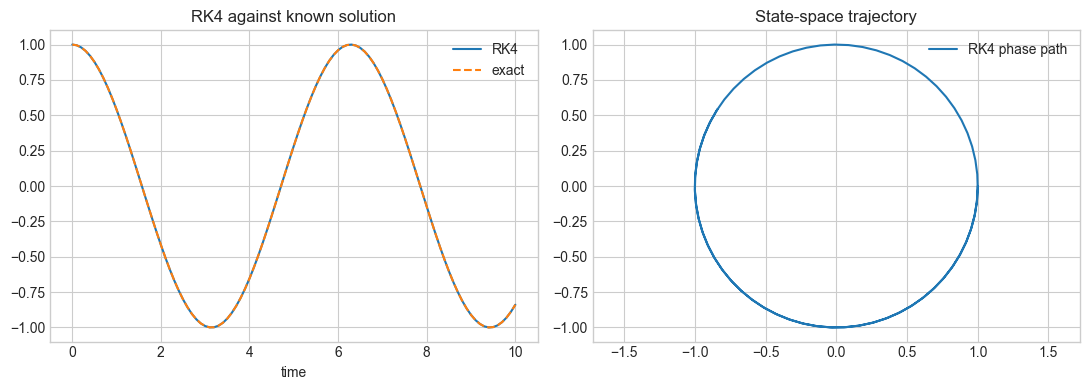

In [7]:
def rk4(field, z0, dt, steps):
    z = np.asarray(z0, dtype=float)
    values = [z.copy()]
    for i in range(steps):
        t = i * dt
        k1 = field(z, t)
        k2 = field(z + .5*dt*k1, t + .5*dt)
        k3 = field(z + .5*dt*k2, t + .5*dt)
        k4 = field(z + dt*k3, t + dt)
        z = z + dt*(k1 + 2*k2 + 2*k3 + k4)/6
        values.append(z.copy())
    return np.asarray(values)

field = lambda z, t: np.array([z[1], -z[0]])
dt = .1
solution = rk4(field, [1, 0], dt, 100)
t = np.arange(101)*dt
exact = np.c_[np.cos(t), -np.sin(t)]
print("maximum state error:", np.abs(solution-exact).max())
fig, ax = plt.subplots(1,2,figsize=(11,4))
ax[0].plot(t, solution[:,0], label='RK4'); ax[0].plot(t, exact[:,0], '--', label='exact')
ax[0].legend(); ax[0].set_title('RK4 against known solution'); ax[0].set_xlabel('time')
ax[1].plot(solution[:,0], solution[:,1], label='RK4 phase path')
ax[1].axis('equal'); ax[1].set_title('State-space trajectory'); ax[1].legend()
plt.tight_layout(); plt.show()

## Multiple shooting

One long nonlinear rollout can create poorly conditioned gradients. I train
three ten-step initial-value problems and penalize disagreement at their
boundaries. Boundary states are derived from training targets only. The model's
public `forward` method cannot accept them.

\[
\mathcal L=\underbrace{\mathcal L_{shoot}}_{\lambda_s=1}
+0.25\underbrace{\mathcal L_{continuity}}_{\text{boundary state}}
+0.5\underbrace{\mathcal L_{full}}_{\text{one inference-like rollout}}.
\]

For boundaries $b=[0,10,20,30]$,

\[
\mathcal L_{shoot}=\frac13\sum_{j=0}^{2}
\operatorname{ADE}(\Phi_\theta(\tilde z_j,10),Y_{b_j:b_{j+1}}).
\]

$\tilde z_0=z_0$; later $\tilde z_j$ reconstruct position and velocity (or
heading/speed/yaw rate) from the training target. Continuity compares the
predicted terminal state with the next reconstructed state. The implementation
batches the three equal-length IVPs into one larger GPU solve; this changes
kernel efficiency, not the mathematical objective.

The full term matters: without it, individually good short segments may still
drift when inference starts only at $z_0$.

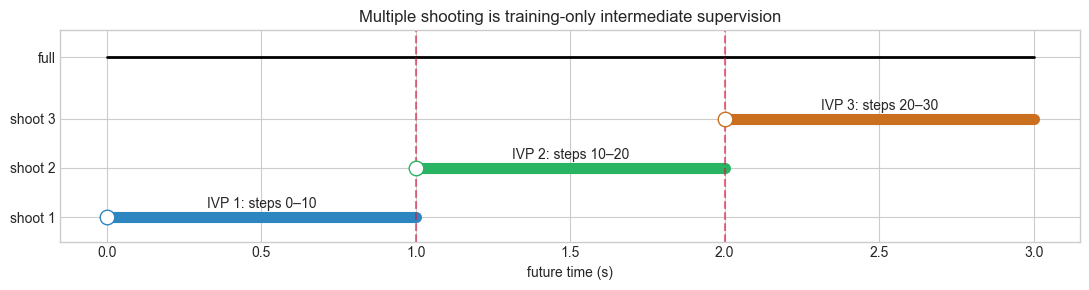

In [8]:
fig, ax = plt.subplots(figsize=(11,3))
colors=["#2e86c1","#28b463","#ca6f1e"]
for j,(a,b) in enumerate(zip([0,10,20],[10,20,30])):
    ax.plot(np.arange(a,b+1)*.1, np.full(b-a+1,j), lw=8, color=colors[j], solid_capstyle='round')
    ax.scatter([a*.1],[j],s=110,facecolor='white',edgecolor=colors[j],zorder=3)
    ax.text((a+b)*.05,j+.18,f"IVP {j+1}: steps {a}–{b}",ha='center')
ax.plot(np.arange(31)*.1, np.full(31,3.25), color='black', lw=2, label='full rollout term')
for x in (1,2): ax.axvline(x,color='crimson',ls='--',alpha=.6)
ax.set_yticks([0,1,2,3.25],["shoot 1","shoot 2","shoot 3","full"])
ax.set_xlabel("future time (s)"); ax.set_title("Multiple shooting is training-only intermediate supervision")
ax.set_ylim(-.5,3.8); plt.tight_layout(); plt.show()

In [9]:
# Gradient growth in the scalar ODE z' = theta*z.
theta = torch.tensor(0.7, requires_grad=True)
z0 = torch.tensor(1.0)
times = torch.arange(1, 31) * .1
prediction = z0 * torch.exp(theta * times)
target = z0 * torch.exp(torch.tensor(.5) * times)
full_loss = ((prediction-target)**2).mean()
full_grad, = torch.autograd.grad(full_loss, theta, retain_graph=True)

short_losses = []
for start in (0, 10, 20):
    local_t = torch.arange(1, 11) * .1
    boundary = z0 * torch.exp(torch.tensor(.5) * (start*.1))
    local_prediction = boundary * torch.exp(theta * local_t)
    local_target = boundary * torch.exp(torch.tensor(.5) * local_t)
    short_losses.append(((local_prediction-local_target)**2).mean())
shooting_loss = torch.stack(short_losses).mean()
shooting_grad, = torch.autograd.grad(shooting_loss, theta)
print(f"full-horizon gradient: {full_grad.item():.3f}")
print(f"mean short-IVP gradient: {shooting_grad.item():.3f}")

full-horizon gradient: 31.515


mean short-IVP gradient: 1.636


## Hybrid vehicle physics

The hybrid uses $z=[x,y,\psi,v,r]$ and makes three derivatives exact:

\[
\dot x=v\cos\psi,\quad \dot y=v\sin\psi,\quad \dot\psi=r,
\quad \dot v=a,\quad \dot r=\alpha_r.
\]

The network learns bounded corrections for $a$ and $\alpha_r$. Current
longitudinal acceleration provides a causal prior that decays as $e^{-t}$.
This improves interpretability but can preserve biased yaw-rate measurements.
Physics narrows the hypothesis space; it does not guarantee better data fit.

| Model | ODE state | Exact derivatives | Learned derivatives |
|---|---|---|---|
| Generic | $[x,y,v_x,v_y]$ | $\dot x=v_x,\dot y=v_y$ | $\dot v_x,\dot v_y$ |
| Hybrid | $[x,y,\psi,v,r]$ | kinematic $x,y,\psi$ | $\dot v,\dot r$ |

In [10]:
from zod_driveformer.dynamics.models import HybridPhysicsNeuralODE
hybrid = HybridPhysicsNeuralODE(
    state_dim=9, history_steps=21, future_steps=30, context_dim=32,
    step_seconds=.1, normalizer_mean=[0]*9, normalizer_scale=[1]*9, hidden_dim=48,
)
state = torch.tensor([[0.,0.,0.,10.,.2]])
context = torch.zeros(1,32); controls = torch.tensor([[1.,.2,.05]])
derivative = hybrid.vector_field(state, context, 0.0, controls)
pd.DataFrame(derivative.detach().numpy(), columns=["dx/dt","dy/dt","dpsi/dt","dv/dt","dr/dt"]).round(3)

,dx/dt,dy/dt,dpsi/dt,dv/dt,dr/dt
0,10.0,0.0,0.2,1.486,-0.076


## What each loss sees

The shooting loss may read future target-derived boundary states during
*training only*. `model.forward(states, valid_mask)` accepts no target argument.
Validation and test call exactly that forward signature and obtain one rollout.
This is supervised learning, not leakage: labels guide optimization, but test
labels never enter model selection or prediction.

In [11]:
models = summary["dynamics"]["models"]
table = []
for name in ("b2_state_mlp", "hybrid_neural_ode", "neural_ode", "temporal_fno"):
    e = models[name]
    table.append([name, e["metrics_across_seeds"]["ade_m"]["mean"],
                  e["latency"]["batch_1_median_ms"], e["parameters"]])
pd.DataFrame(table, columns=["model","ADE_m","latency_ms","parameters"]).round(4)

,model,ADE_m,latency_ms,parameters
0,b2_state_mlp,0.6732,0.2013,112444
1,hybrid_neural_ode,0.5507,35.7466,108674
2,neural_ode,0.5435,24.1673,108162
3,temporal_fno,0.5424,2.5837,1230242


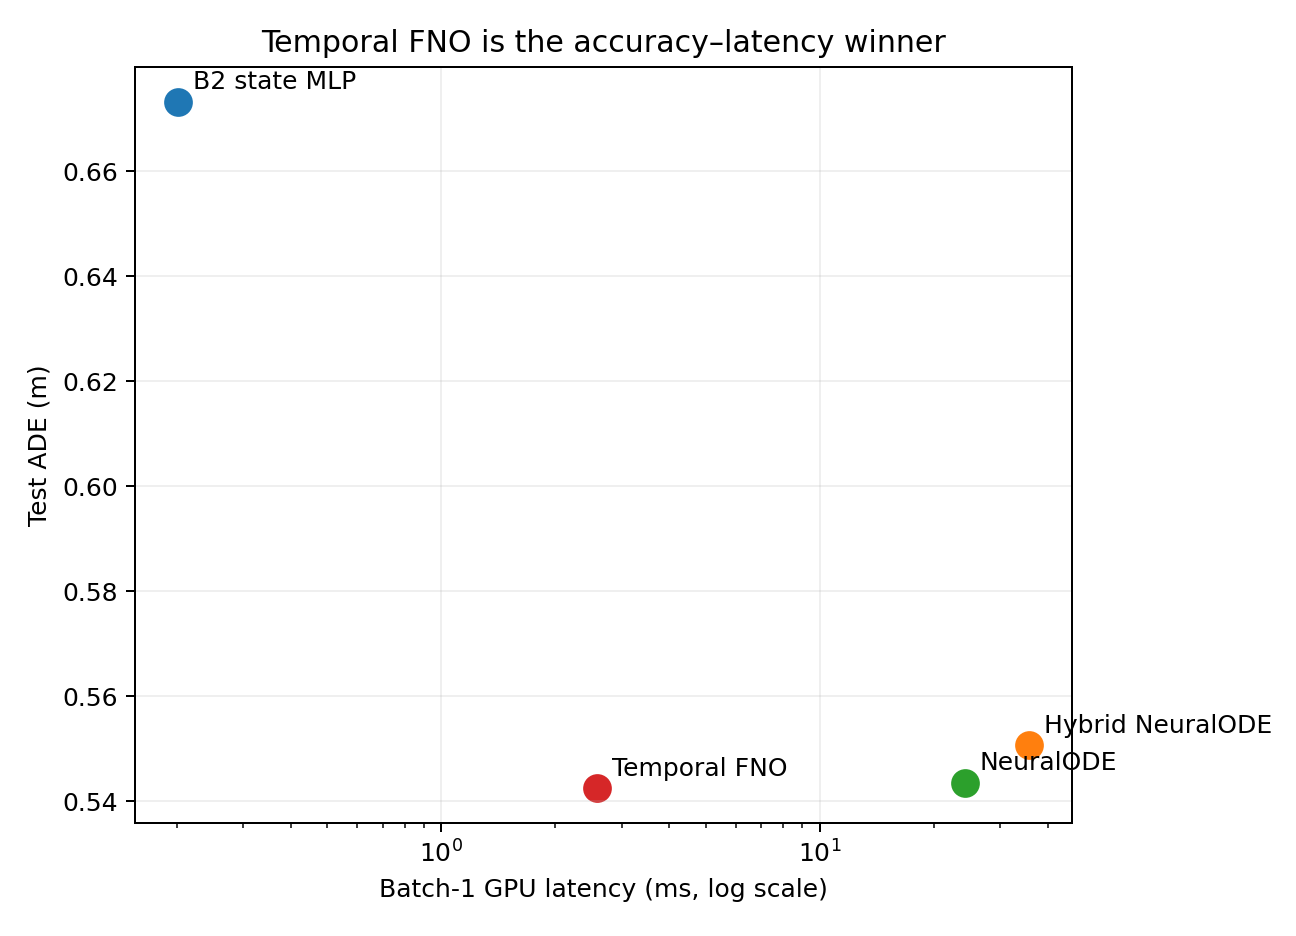

In [12]:
from IPython.display import Image, display
display(Image(filename=str(ROOT/'reports/figures/dynamics_accuracy_latency.png')))

## From a scalar metric back to a path

ADE compresses thirty two-dimensional errors into one number. Projecting the
paths through the calibrated fisheye camera restores the scene geometry: I can
see where models agree early and how endpoint or turn error accumulates. This is
diagnostic context only; every forecasting network remains state-only.

![Camera-projected trajectories](../reports/figures/dynamics_camera_predictions.png)

## Interpretation

NeuralODE and hybrid ODE reliably beat B2, supporting the continuous-dynamics
hypothesis on this test role. The generic ODE is slightly better than the
physics hybrid. Temporal FNO has only 0.0011 m lower ADE than NeuralODE—far too
small to sell as a substantive accuracy victory—but is about nine times faster
at batch 1, so it is the engineering winner.

### Check my understanding

1. RK4 is the numerical solver; $f_	heta$ is the learned vector field.
2. Multiple shooting changes training supervision, not the inference API.
3. The hybrid is interpretable because three state derivatives are exact.
4. A physics prior can lose when its assumptions or measured controls are biased.